In [ ]:
from analyzer import * 
import seaborn as sns 

sns.set_theme(
    style="whitegrid",
    context="paper",
) 

vv = VQAResults()   
human_vqa = vv.human 
model_vqa = vv.model 

mm = MMStarResults()

model_mmstar = mm.model

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Loading VQA annotations from /home/work/yuna/VLMEval/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
[]
[]


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:393: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)
/home/work/yuna/HPA/evaluation/analysis/analyzer.py:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.human['correct'] = self.human['correct'] * 100


[]


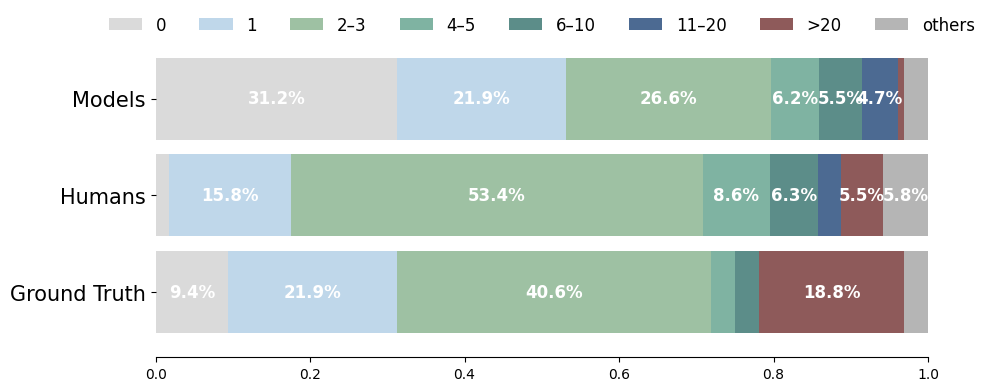

In [ ]:
from utils.vqa import bin_number 

def filter_answer_type(df, answer_type, col):
    
    df = df[df['model'].isin(pretrained_models + ['Humans'])]
    df = df[df['answer_type'] == answer_type].copy()
    df['output'] = df[col] 

    if answer_type == 'yes/no': 
        df = yes_or_no(df)
    else: 
        df = df[df['question_type'] != 'what time']
        df['output'] = df[col].apply(lambda x: pp.postprocess_answer(x.lower()))
        df['number'] = df['output'].apply(extract_number_or_other) 
        df['number_bin'] = df['number'].apply(bin_number) 

    return df 

pp = PostProcessor() 
h = filter_answer_type(vv.human, 'number', 'answer_normalized')
m = filter_answer_type(vv.model, 'number', 'output') 
gt = filter_answer_type(vv.model, 'number', 'multiple_choice_answer')  

plot_df = pd.concat([
    gt[['number_bin']].assign(source='Ground Truth'),
    h[['number_bin']].assign(source='Humans'),
    m[['number_bin']].assign(source='Models')
])
counts = (
    plot_df
    .value_counts(['source', 'number_bin'])
    .reset_index(name='count')
)

counts['proportion'] = (
    counts
    .groupby('source')['count']
    .transform(lambda x: x / x.sum())
) 
stack_df = (
    counts
    .pivot(index='source', columns='number_bin', values='proportion')
    .fillna(0)
)
colors = {
    '0': '#DADADA',
    '1': '#BFD7EA',
    '2–3': '#9EC1A3',
    '4–5': '#7FB3A2',
    '6–10': '#5C8D89',
    '11–20': '#4C6A92',
    '>20': '#8E5A5A',
    'others': '#B5B5B5'
}

order = ['0','1','2–3','4–5','6–10','11–20','>20','others'] 

fig, ax = plt.subplots(figsize=(10,4))

stack_df[order].plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=[colors[c] for c in order],
    width=0.85
)

ax.set_xlim(0, 1)
# ax.set_xlabel('Proportion')
ax.set_ylabel('')
ax.grid(False)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# percentage labels
for i, source in enumerate(stack_df.index):
    cum = 0
    for cat in order:
        val = stack_df.loc[source, cat]
        if val > 0.04:
            ax.text(
                cum + val / 2,
                i,
                f'{val*100:.1f}%',
                ha='center',
                va='center',
                color='white',
                fontsize=12,
                fontweight='bold'
            )
        cum += val
ax.tick_params(axis='y', labelsize=15)
ax.legend(
    bbox_to_anchor=(0.5, 1.1),
    loc='upper center',
    ncol=8,
    frameon=False, 
    fontsize=12
)

# plt.title('Numeric Answer Distribution (Binned & Normalized)')
plt.tight_layout()
plt.show()

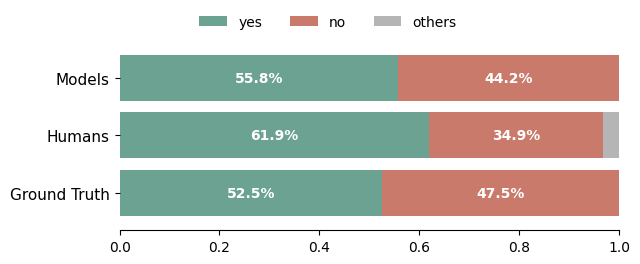

In [10]:
colors = {
    'yes': '#6BA292',     # muted teal
    'no': '#C97A6A',      # muted coral
    'others': '#B5B5B5'   # neutral gray
}

h = filter_answer_type(vv.human, 'yes/no', 'answer_normalized')
m = filter_answer_type(vv.model, 'yes/no', 'output') 
gt = filter_answer_type(vv.model, 'yes/no', 'multiple_choice_answer')

counts = (
    plot_df
    .value_counts(['source', 'y/n'])
    .reset_index(name='count')
)

counts['proportion'] = (
    counts
    .groupby('source')['count']
    .transform(lambda x: x / x.sum())
)

stack_df = (
    counts
    .pivot(index='source', columns='y/n', values='proportion')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(6.5, 2.8))

stack_df[['yes', 'no', 'others']].plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=[colors[c] for c in ['yes', 'no', 'others']],
    width=0.8   # ✅ thicker bars
)

# --- Aesthetics ---
ax.set_xlim(0, 1)
# ax.set_xlabel('Proportion', fontsize=11)
ax.set_ylabel('')
ax.set_yticklabels(stack_df.index, fontsize=11)
ax.grid(False)

# Remove spines for clean look
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# --- Percentage labels inside bars ---
for i, source in enumerate(stack_df.index):
    cum = 0
    for cat in ['yes', 'no', 'others']:
        val = stack_df.loc[source, cat]
        if val > 0.04:  # avoid clutter on tiny segments
            ax.text(
                cum + val / 2,
                i,
                f'{val*100:.1f}%',
                ha='center',
                va='center',
                color='white',
                fontsize=10,
                fontweight='bold'
            )
        cum += val

# --- Legend outside, 2 columns ---
ax.legend(
    loc='upper right',
    bbox_to_anchor=(0.7, 1.2),
    ncol=3,
    frameon=False
)

# plt.title('Yes / No Answer Distribution (Normalized)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
vv.human.answer_type.unique() # , vv.model 

array(['yes/no', 'number', 'other'], dtype=object)

In [ ]:
df = mm.combine_mh 

mean                          \
                                  correct                           
category                coarse perception fine-grained perception   
model                                                               
Humans                          28.232355               26.287129   
InternVL 3.5 (1B)               25.000000               29.702970   
InternVL 3.5 (2B)               20.588235               25.742574   
InternVL 3.5 (4B)               20.588235               25.742574   
InternVL 3.5 (8B)               27.941176               32.673267   
LLaVA-v1.5 (7B)                 36.764706               27.722772   
LLaVA-v1.6-Mistral (7B)         25.000000               24.752475   
LLaVA-v1.6-Vicuna (7B)          32.352941               20.792079   
Qwen3 (4B)                      25.000000               33.663366   
Qwen3 (8B)                      17.647059               29.702970   
Qwen3-VL (2B)                   30.882353               28.712871   
Qwen3-VL (4B)                   17.647059               34.653465   
Qwen3-VL (8B)                   30.882353               30.693069   
Total Average                   27.430699               27.196782   

                                                              \
                                                               
category                instance reasoning logical reasoning   
model                                                          
Humans                           28.365792         27.745665   
InternVL 3.5 (1B)                29.090909         27.272727   
InternVL 3.5 (2B)                18.181818         36.363636   
InternVL 3.5 (4B)                25.454545         31.818182   
InternVL 3.5 (8B)                27.272727         63.636364   
LLaVA-v1.5 (7B)                  29.090909         27.272727   
LLaVA-v1.6-Mistral (7B)          21.818182         31.818182   
LLaVA-v1.6-Vicuna (7B)           30.909091         18.181818   
Qwen3 (4B)                       23.636364         40.909091   
Qwen3 (8B)                       20.000000         59.090909   
Qwen3-VL (2B)                    21.818182         22.727273   
Qwen3-VL (4B)                    25.454545         40.909091   
Qwen3-VL (8B)                    30.909091         50.000000   
Total Average                    27.267789         31.034483   

                                                            
                                                            
category                science & technology Total Average  
model                                                       
Humans                             10.000000     27.410597  
InternVL 3.5 (1B)                   0.000000     27.935223  
InternVL 3.5 (2B)                   0.000000     23.481781  
InternVL 3.5 (4B)                   0.000000     24.696356  
InternVL 3.5 (8B)                   0.000000     32.793522  
LLaVA-v1.5 (7B)                   100.000000     30.769231  
LLaVA-v1.6-Mistral (7B)             0.000000     24.696356  
LLaVA-v1.6-Vicuna (7B)            100.000000     26.315789  
Qwen3 (4B)                               NaN     29.674797  
Qwen3 (8B)                          0.000000     26.720648  
Qwen3-VL (2B)                       0.000000     27.125506  
Qwen3-VL (4B)                       0.000000     28.340081  
Qwen3-VL (8B)                       0.000000     32.388664  
Total Average                      12.903226     27.589114

## Agreement 

In [ ]:
 model_corr # get_corr

,index,subj,corr,category
0,InternVL 3.5 (1B),02f952bb_20251210_230336,0.448276,coarse perception
1,InternVL 3.5 (2B),02f952bb_20251210_230336,0.623698,coarse perception
2,InternVL 3.5 (4B),02f952bb_20251210_230336,0.490885,coarse perception
3,InternVL 3.5 (8B),02f952bb_20251210_230336,0.480916,coarse perception
4,LLaVA-v1.5 (7B),02f952bb_20251210_230336,0.180106,coarse perception
...,...,...,...,...
235,Qwen3-VL (2B),f616d5c7_20251203_212223,-0.028777,logical reasoning
236,Qwen3-VL (4B),f616d5c7_20251203_212223,0.047244,logical reasoning
237,Qwen3-VL (8B),f616d5c7_20251203_212223,-0.181818,logical reasoning
238,Qwen3 (4B),f616d5c7_20251203_212223,-0.125984,logical reasoning


In [168]:
# model_corr.groupby(['index'])['corr'].mean().to_latex(f"./tables/appendix/mmstar-ac1-model.tex", float_format="%.1f") 
model_corr = model_corr.pivot_table(
    index='index', 
    columns=['category'], 
    values=['corr'], 
    aggfunc='mean'
)
model_corr.to_latex(f"./tables/appendix/mmstar-ac1-model-cat.tex", float_format="%.3f")  
model_corr 

corr                          \
category                coarse perception fine-grained perception   
index                                                               
InternVL 3.5 (1B)                0.375680                0.355762   
InternVL 3.5 (2B)                0.415034                0.443534   
InternVL 3.5 (4B)                0.386983                0.419558   
InternVL 3.5 (8B)                0.287350                0.372764   
LLaVA-v1.5 (7B)                  0.195631                0.414145   
LLaVA-v1.6-Mistral (7B)          0.358164                0.437181   
LLaVA-v1.6-Vicuna (7B)           0.299245                0.464113   
Qwen3 (4B)                       0.415512                0.304194   
Qwen3 (8B)                       0.444586                0.400733   
Qwen3-VL (2B)                    0.304713                0.388003   
Qwen3-VL (4B)                    0.438574                0.329424   
Qwen3-VL (8B)                    0.299055                0.422788   

                                                              
category                instance reasoning logical reasoning  
index                                                         
InternVL 3.5 (1B)                 0.365645          0.295850  
InternVL 3.5 (2B)                 0.453132          0.228304  
InternVL 3.5 (4B)                 0.390769          0.314116  
InternVL 3.5 (8B)                 0.435644         -0.136593  
LLaVA-v1.5 (7B)                   0.382508          0.240151  
LLaVA-v1.6-Mistral (7B)           0.449847          0.230977  
LLaVA-v1.6-Vicuna (7B)            0.312529          0.377256  
Qwen3 (4B)                        0.429729          0.227101  
Qwen3 (8B)                        0.484684         -0.193553  
Qwen3-VL (2B)                     0.386485          0.312420  
Qwen3-VL (4B)                     0.416434          0.184645  
Qwen3-VL (8B)                     0.328212         -0.032008

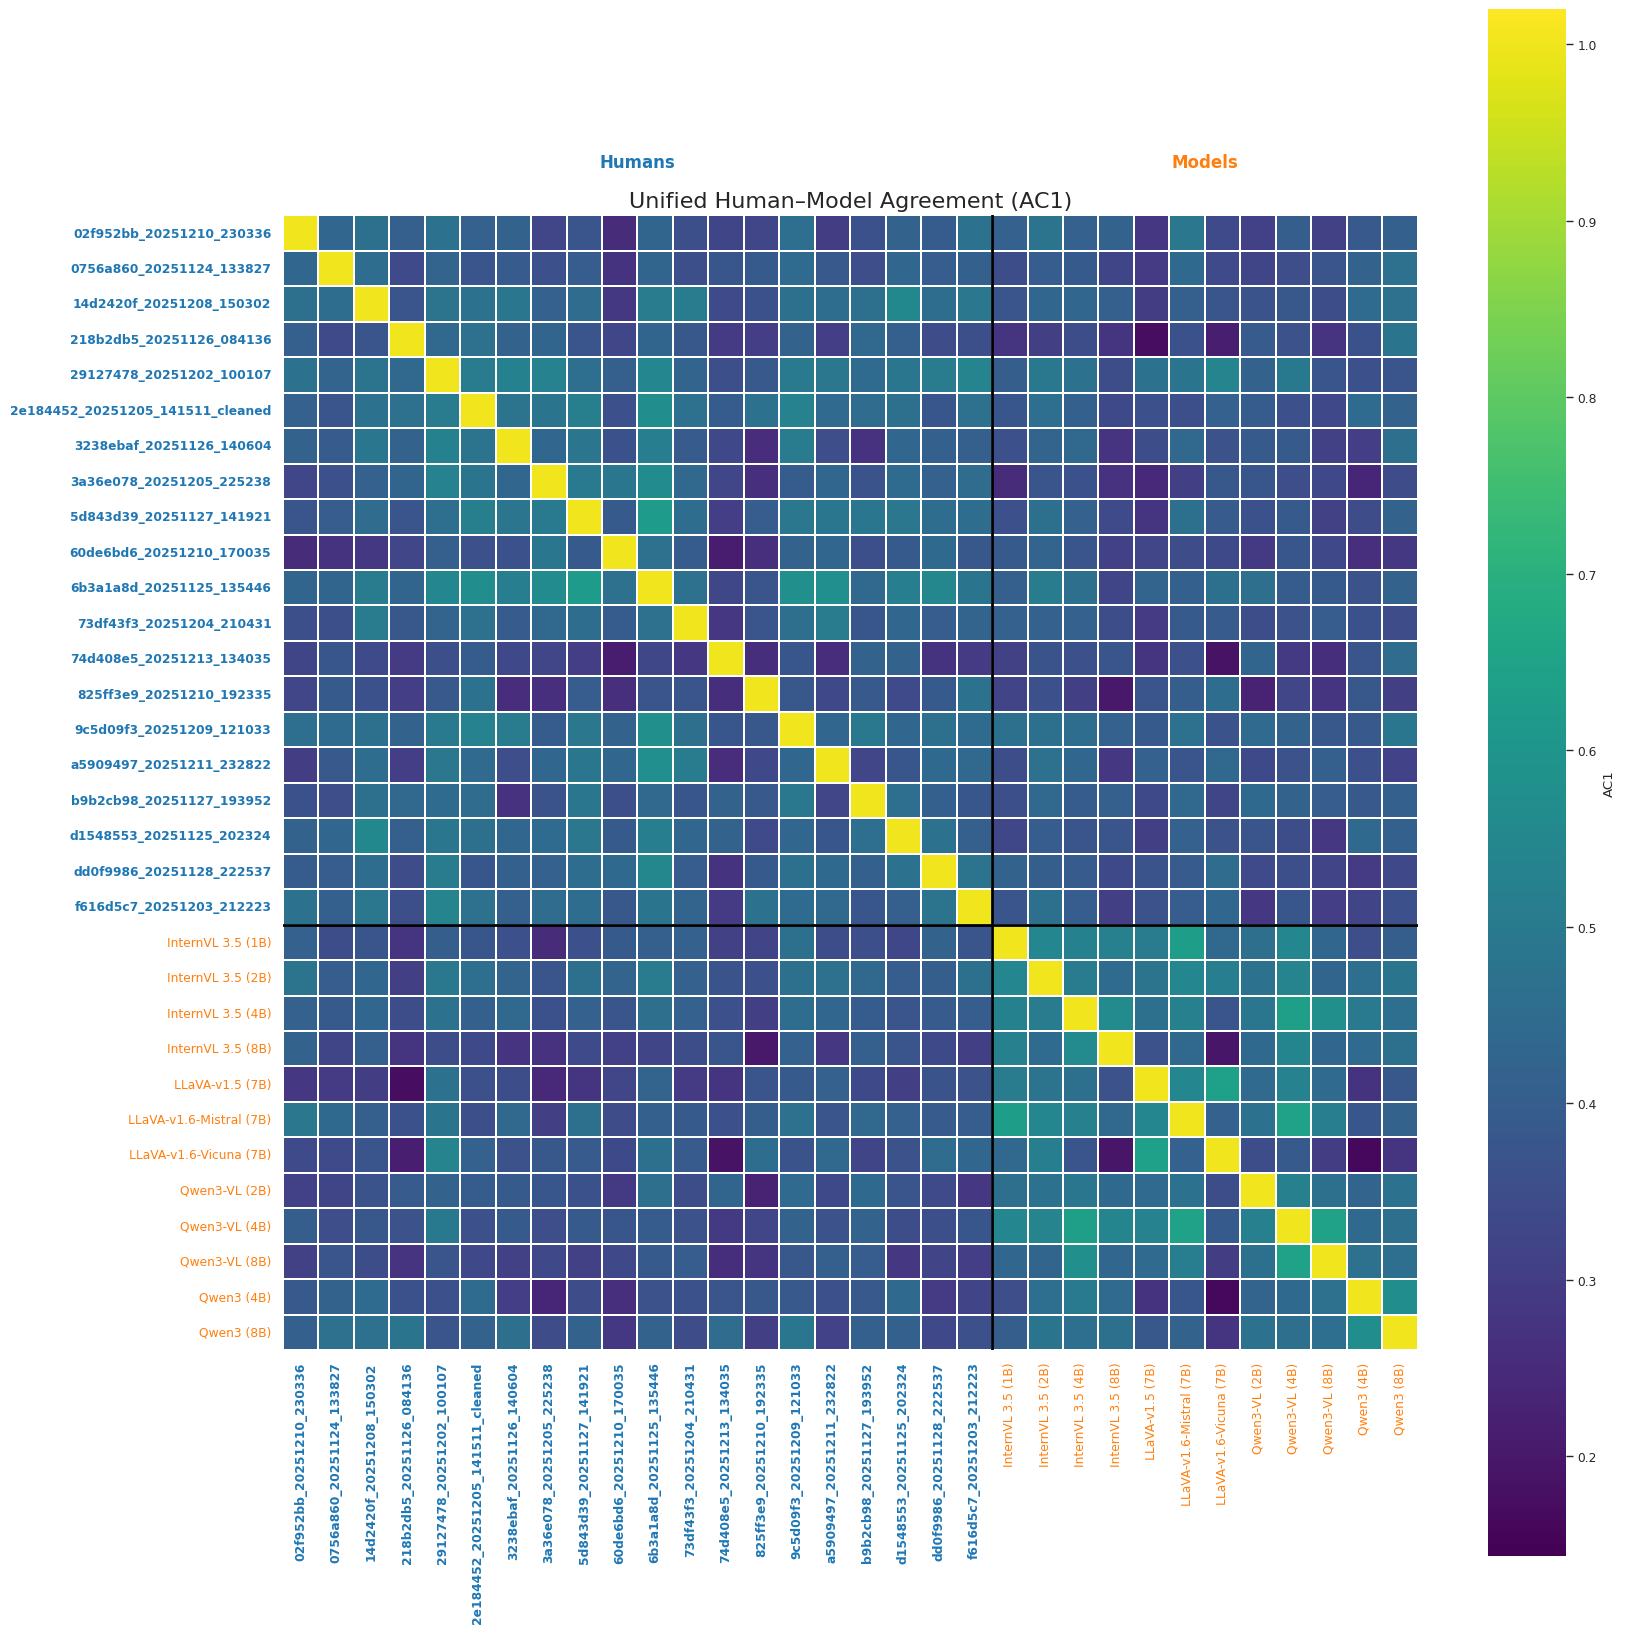

In [ ]:
res = interrater_agreement_ac1(
    answers_pivot,
    grp1=all_raters,
    grp2=all_raters,
    n_boot=0,
    plot=True,
) 
plot_unified_agreement_heatmap(res['corr_mat'], list(humans), list(models), title="Unified Human–Model Agreement (AC1)", metric_label="AC1")

In [99]:
results = pd.merge(df.groupby(["category",	"l2_category"]).agg({'correct': 'mean', 'question':'nunique'}).reset_index(),
        blind.groupby(["category",	"l2_category"])['correct'].mean().reset_index(), 
        on=["category",	"l2_category"], suffixes=('_human', '_model')
        )
        
results['diff'] = np.abs(results['correct_model'] - results['correct_human'])
results.sort_values(by=['diff']) 

,category,l2_category,correct_human,question,correct_model,diff
8,instance reasoning,single-instance reasoning,0.343750,4,0.340909,0.002841
13,math,numeric commonsense and calculation,0.250000,1,0.242857,0.007143
10,logical reasoning,common reasoning,0.240385,13,0.232877,0.007508
3,fine-grained perception,localization,0.125000,1,0.083333,0.041667
2,coarse perception,image style & quality,0.250000,2,0.291667,0.041667
0,coarse perception,image emotion,0.375000,4,0.289474,0.085526
15,science & technology,biology & chemistry & physics,0.187500,2,0.100000,0.087500
5,fine-grained perception,recognition,0.321429,7,0.208333,0.113095
11,logical reasoning,diagram reasoning,0.166667,6,0.280488,0.113821
12,math,geometry,0.270000,25,0.390000,0.120000
